# Two-Qubit Gates with Qiskit

This notebook is designed for Qiskit SDK 2.x.
You will.
- Install and verify Qiskit 2.x
- Build several quantum circuits
- Run them on an ideal simulator

In [15]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

from typing import Dict

print("Qiskit version.", qiskit.__version__)

Qiskit version. 2.2.3


## 1. Helper utilities
Some small helper functions for running circuits and plotting results.

In [9]:
def run_and_plot_counts(circ, backend, shots = 1024, title = None) -> Dict[str, int]:
    """Run a circuit on a backend and return plus plot counts.

    Works with AerSimulator and other backends that support .run()."""

    job = backend.run(circ, shots=shots)
    result = job.result()
    counts = result.get_counts(0)
    display(plot_histogram(counts, title=title))
    return counts

## 2. Single qubit superposition circuit
Create a one qubit circuit.
Apply a Hadamard gate to get a superposition.
Then measure in the computational basis.

<IPython.core.display.Latex object>

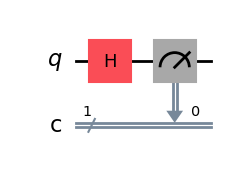

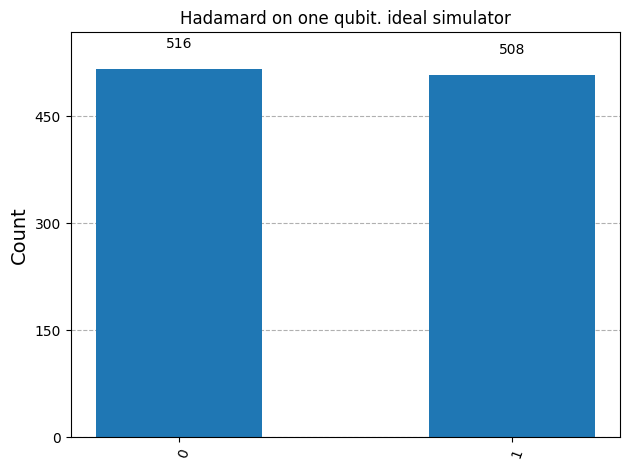

{'1': 508, '0': 516}


In [ ]:
# Single qubit superposition
qc_h = QuantumCircuit(1, 1)
qc_h.h(0)
sv_h = Statevector.from_instruction(qc_h)
display(sv_h.draw('latex', prefix="|ψ⟩ = "))
qc_h.measure(0, 0)

display(qc_h.draw(output='mpl'))

# Ideal simulator backend.
ideal_sim = AerSimulator()
counts_h = run_and_plot_counts(qc_h, ideal_sim, shots=1024, title="Hadamard on one qubit. ideal simulator")
print(counts_h)

## 3. Two qubit Bell state circuit
Now we create a two qubit entangled state.
We apply a Hadamard on qubit 0 then a CNOT from 0 to 1.

<IPython.core.display.Latex object>

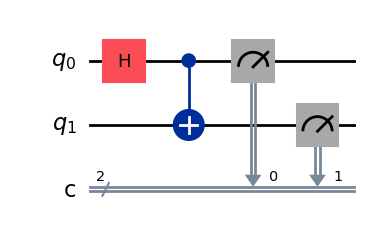

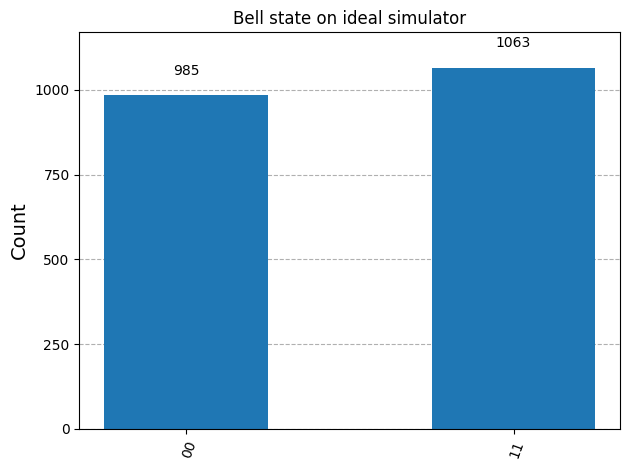

{'00': 985, '11': 1063}


In [11]:
# Bell state circuit
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
sv_bell = Statevector.from_instruction(qc_bell)
display(sv_bell.draw('latex', prefix="|ψ⟩ = "))
qc_bell.measure([0, 1], [0, 1])

display(qc_bell.draw(output='mpl'))

counts_bell = run_and_plot_counts(qc_bell,
                                  ideal_sim,
                                  shots=2048,
                                  title="Bell state on ideal simulator")
print(counts_bell)

## 4. Three qubit GHZ state circuit
We move to three qubits to build a GHZ state.
This lets you see how entanglement scales with more qubits.

<IPython.core.display.Latex object>

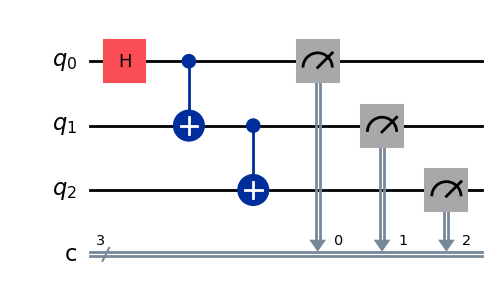

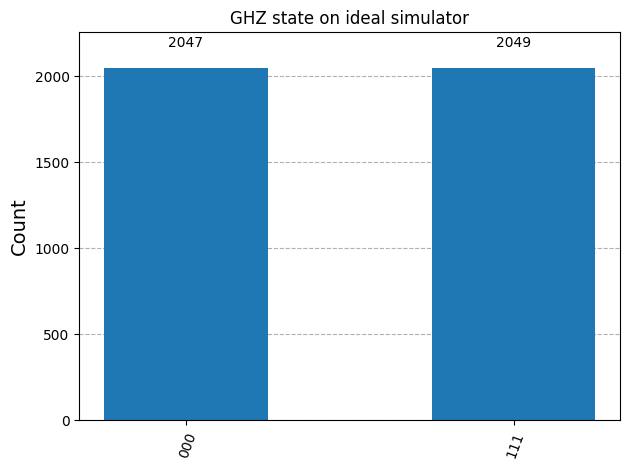

{'111': 2049, '000': 2047}


In [12]:
# Three qubit GHZ state
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)
sv_ghz = Statevector.from_instruction(qc_ghz)
display(sv_ghz.draw('latex', prefix="|ψ⟩ = "))
qc_ghz.measure([0, 1, 2], [0, 1, 2])

display(qc_ghz.draw(output='mpl'))

counts_ghz = run_and_plot_counts(qc_ghz,
                                 ideal_sim,
                                 shots=4096,
                                 title="GHZ state on ideal simulator")
print(counts_ghz)

<IPython.core.display.Latex object>

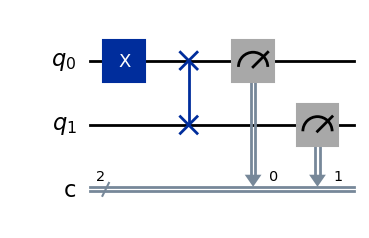

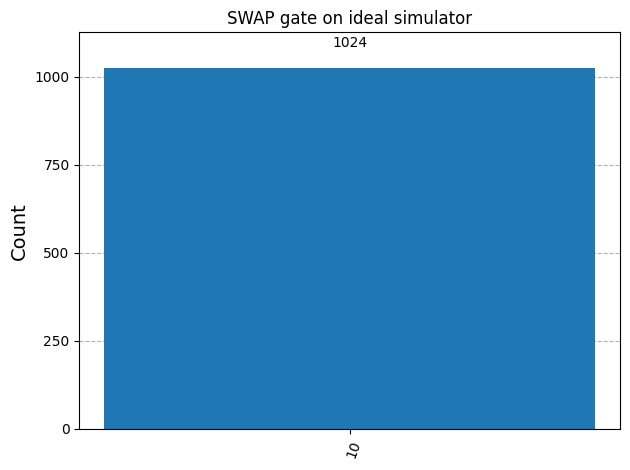

{'10': 1024}


In [13]:
qc_swap = QuantumCircuit(2, 2)
qc_swap.x(0)
qc_swap.swap(0, 1)
sv_swap = Statevector.from_instruction(qc_swap)
display(sv_swap.draw('latex', prefix="|ψ⟩ = "))
qc_swap.measure([0, 1], [0, 1])

display(qc_swap.draw(output='mpl'))

counts_swap = run_and_plot_counts(qc_swap,
                                  ideal_sim,
                                  shots=1024,
                                  title="SWAP gate on ideal simulator")
print(counts_swap)

<IPython.core.display.Latex object>

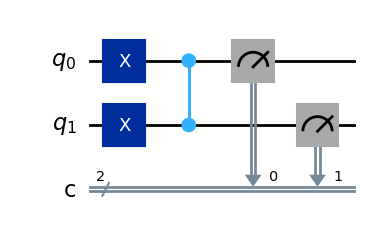

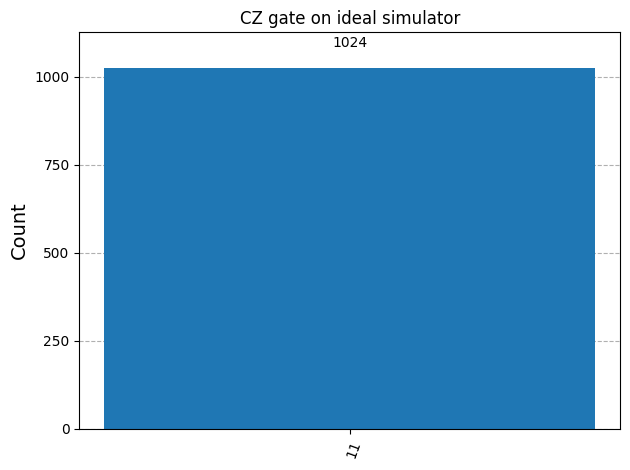

{'11': 1024}


In [14]:
qc_cz = QuantumCircuit(2, 2)
qc_cz.x([0,1])
qc_cz.cz(0, 1)
sv_cz = Statevector.from_instruction(qc_cz)
display(sv_cz.draw('latex', prefix="|ψ⟩ = "))
qc_cz.measure([0, 1], [0, 1])

display(qc_cz.draw(output='mpl'))

counts_cz = run_and_plot_counts(qc_cz,
                                ideal_sim,
                                shots=1024,
                                title="CZ gate on ideal simulator")
print(counts_cz)

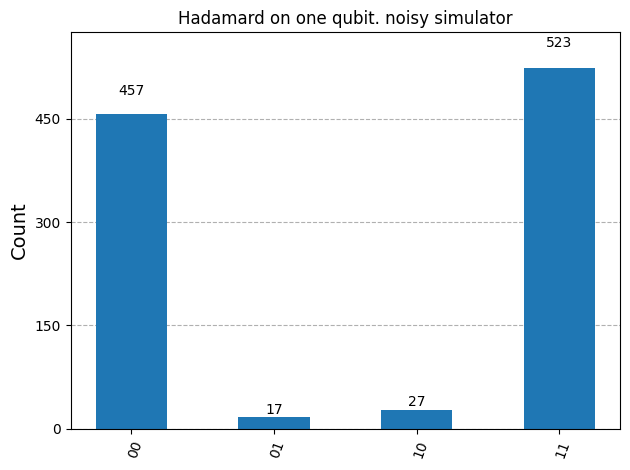

{'01': 17, '11': 523, '10': 27, '00': 457}


In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

backend = FakeSherbrooke()

counts_h_noisy = run_and_plot_counts(qc_bell,
                                     backend,
                                     shots=1024,
                                     title="Hadamard on one qubit. noisy simulator")
print(counts_h_noisy)